In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Resampling and Modeling
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics (Part 3 Requirements)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

print("✅ Cell 1 Complete: All libraries imported successfully.")

✅ Cell 1 Complete: All libraries imported successfully.


In [2]:
# Cell 2: Load Data using Relative Paths
# The '../' tells Jupyter to go up one folder, then into the dataset folder
train_path = '../cleaned_project_dataset/train_baseline.parquet'
test_path = '../cleaned_project_dataset/test_baseline.parquet'

print("Loading baseline datasets...")
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Split Features (X) and Target (y)
X_train = train_df.drop(columns=['Label'])
y_train = train_df['Label']

X_test = test_df.drop(columns=['Label'])
y_test = test_df['Label']

print(f"✅ Cell 2 Complete.")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Loading baseline datasets...
✅ Cell 2 Complete.
Training Features Shape: (362479, 77)
Testing Features Shape: (90620, 77)


In [3]:
# Cell 3: Hybrid Upsampling Strategy
# We boost any class with fewer than 10,000 rows up to 10,000. 
# Large classes (like Benign or Hulk) are left completely alone.
target_threshold = 10000
sampling_strategy = {}

for label_idx, count in Counter(y_train).items():
    if count < target_threshold:
        sampling_strategy[label_idx] = target_threshold
    else:
        sampling_strategy[label_idx] = count

print("Applying Random Over-Sampling to minority classes...")
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("✅ Cell 3 Complete.")
print("Original Training class distribution:", Counter(y_train))
print("Resampled Training class distribution:", Counter(y_train_resampled))

Applying Random Over-Sampling to minority classes...
✅ Cell 3 Complete.
Original Training class distribution: Counter({5: 80000, 1: 80000, 3: 80000, 0: 80000, 4: 33125, 7: 7926, 2: 1384, 6: 44})
Resampled Training class distribution: Counter({5: 80000, 1: 80000, 3: 80000, 0: 80000, 4: 33125, 7: 10000, 2: 10000, 6: 10000})


In [4]:
# Cell 4: Initialize and Train Random Forest
print("Initializing Optimized Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,               
    max_depth=20,                   # Prevent overfitting on the duplicated minority rows
    min_samples_leaf=5,             
    class_weight='balanced_subsample', # Handle the remaining imbalance perfectly
    random_state=42,                
    n_jobs=-1,                      # Use all CPU cores for speed
    verbose=1                       # Show progress
)

print("Training the model (this may take a minute)...")
rf_model.fit(X_train_resampled, y_train_resampled)

# Generate Predictions for Evaluation
print("\nGenerating predictions on Test Set...")
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test) # Required for ROC/AUC

print("✅ Cell 4 Complete: Model Trained and Predictions Generated!")

Initializing Optimized Random Forest Classifier...
Training the model (this may take a minute)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   33.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s



Generating predictions on Test Set...


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


✅ Cell 4 Complete: Model Trained and Predictions Generated!


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished


In [5]:
# Cell 5: Standard Metrics Evaluation
# We use average='macro' so that the tiny classes carry equal weight in the final score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print("--- GLOBAL PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (Macro Average)")
print(f"Recall:    {recall:.4f} (Macro Average)")
print(f"F1-Score:  {f1:.4f} (Macro Average)")

print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, zero_division=0))
print("✅ Cell 5 Complete.")

--- GLOBAL PERFORMANCE METRICS ---
Accuracy:  0.9992
Precision: 0.9930 (Macro Average)
Recall:    0.9995 (Macro Average)
F1-Score:  0.9962 (Macro Average)

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       1.00      1.00      1.00     20000
           2       0.95      1.00      0.97       346
           3       1.00      1.00      1.00     20000
           4       1.00      1.00      1.00      8281
           5       1.00      1.00      1.00     20000
           6       1.00      1.00      1.00        11
           7       1.00      1.00      1.00      1982

    accuracy                           1.00     90620
   macro avg       0.99      1.00      1.00     90620
weighted avg       1.00      1.00      1.00     90620

✅ Cell 5 Complete.


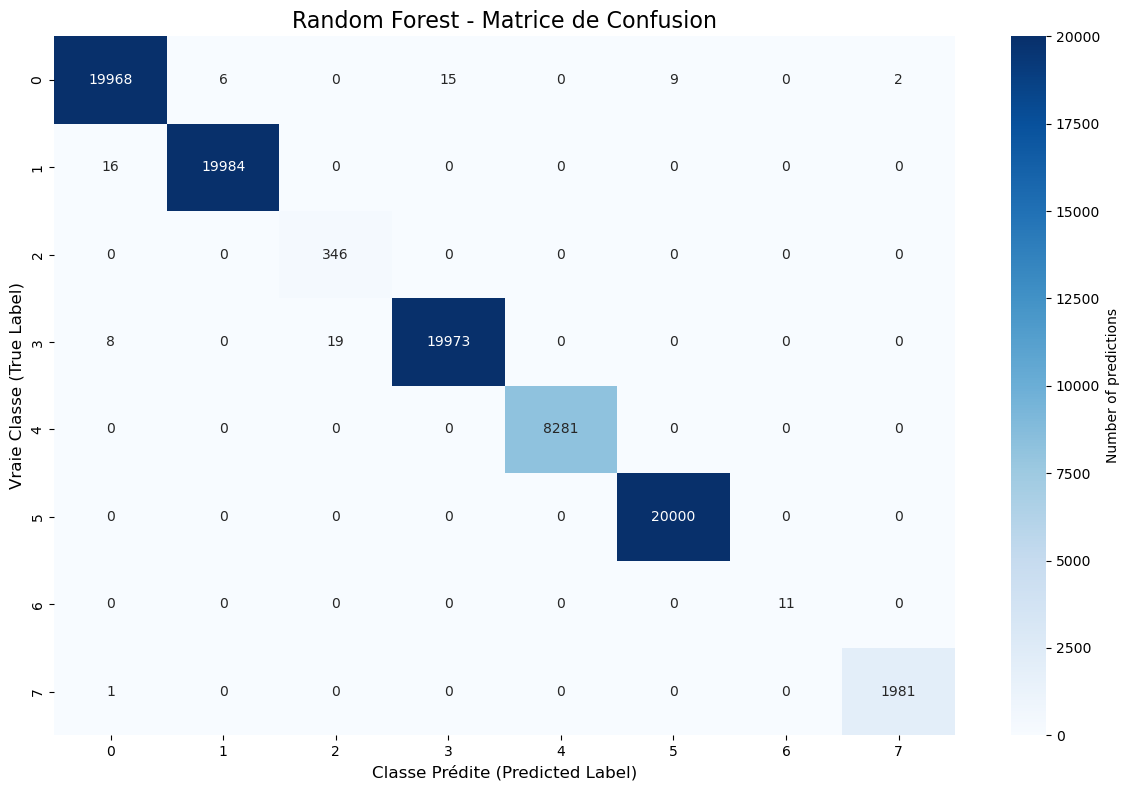

✅ Cell 6 Complete.


In [6]:
# Cell 6: Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
# Using log scale for colors because Benign numbers are massive compared to attacks
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Number of predictions'})

plt.title('Random Forest - Matrice de Confusion', fontsize=16)
plt.ylabel('Vraie Classe (True Label)', fontsize=12)
plt.xlabel('Classe Prédite (Predicted Label)', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Cell 6 Complete.")

Global ROC AUC Score (Macro OVR): 1.0000


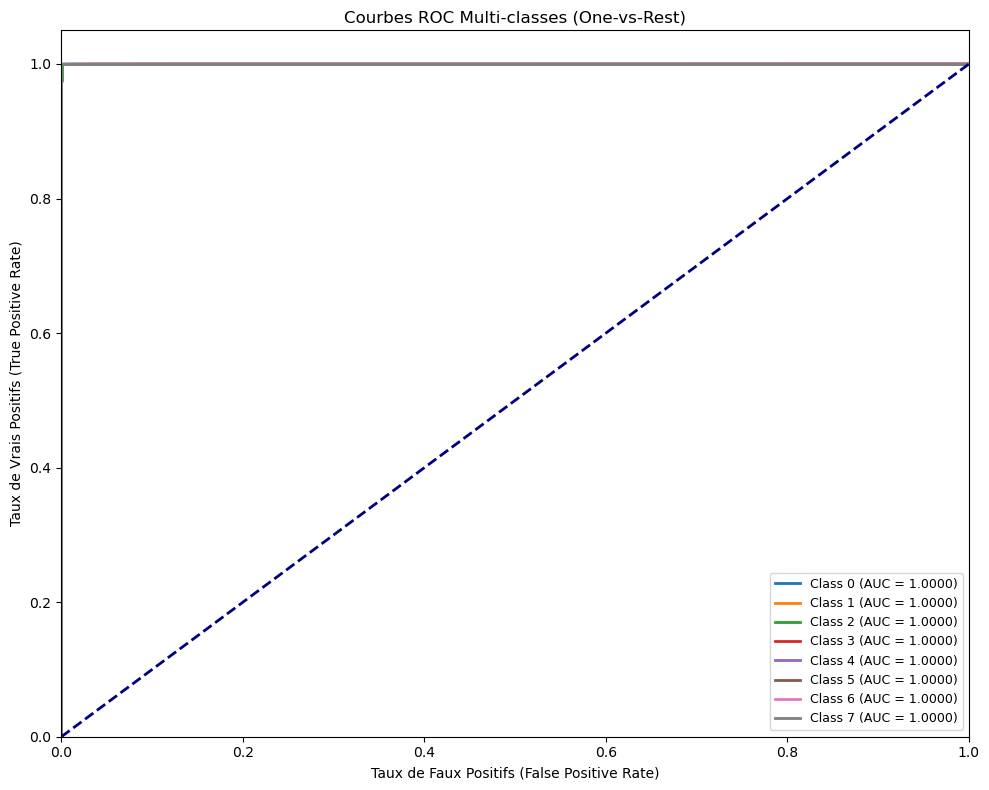

✅ Cell 7 Complete.


In [7]:
# Cell 7: ROC AUC Score Calculation
# Calculate Global Macro AUC
roc_auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f"Global ROC AUC Score (Macro OVR): {roc_auc_macro:.4f}")

# Plotting ROC Curves for each class
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    class_auc = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_label} (AUC = {class_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (False Positive Rate)')
plt.ylabel('Taux de Vrais Positifs (True Positive Rate)')
plt.title('Courbes ROC Multi-classes (One-vs-Rest)')
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("✅ Cell 7 Complete.")

C:\Users\01\AppData\Local\Temp\ipykernel_29552\575458875.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette="mako")


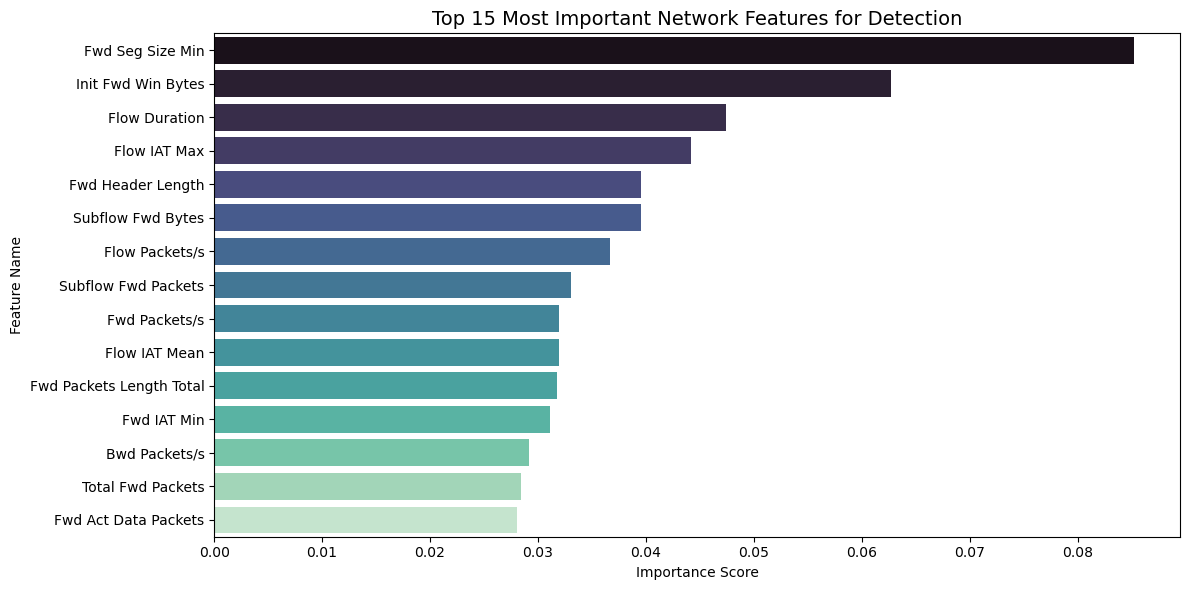

In [8]:
# Cell 8: Feature Importances
importances = rf_model.feature_importances_
feature_names = X_train.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette="mako")
plt.title("Top 15 Most Important Network Features for Detection", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()